# 03 - Análisis exploratorio de datos

## Objetivo

Explorar las relaciones entre las características de los clientes y la variable objetivo `Churn`, con el propósito de identificar patrones que puedan estar asociados con la cancelación del servicio.

Durante esta etapa se analizarán variables numéricas y categóricas mediante estadísticas descriptivas y visualizaciones. Los patrones encontrados serán considerados como asociaciones observadas en los datos y no como relaciones causales.

In [45]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt



DATA_PATH = Path('../data/processed/Telco-Customer-Churn-clean.csv')

df = pd.read_csv(DATA_PATH)

In [46]:
df.shape

(7043, 21)

### Funciones auxiliares para variables categóricas

In [62]:
def churn_count(df, column):
    table = pd.crosstab(
        df[column],
        df["Churn"]
    )

    return table

def churn_percentage(df, column):
    table = (
        pd.crosstab(
            df[column],
            df["Churn"],
            normalize="index"
        ) * 100
    ).round(2)

    return table

## 1. Relación entre antigüedad y Churn

Se analiza la distribución de `tenure` entre los clientes que permanecen en la compañía y aquellos que presentan `Churn`, con el fin de identificar posibles diferencias en la antigüedad de ambos grupos.

In [47]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


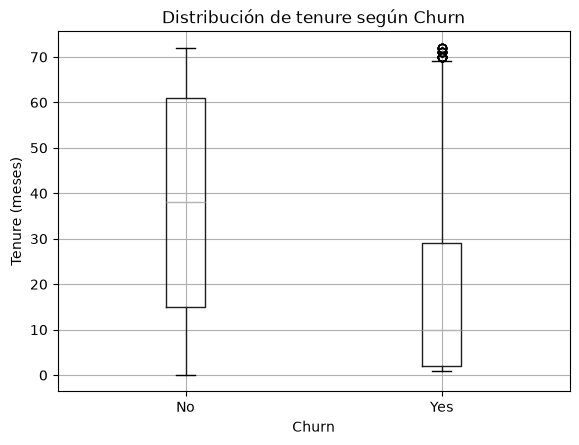

In [48]:
df.boxplot(column="tenure", by="Churn")

plt.title("Distribución de tenure según Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (meses)")
plt.show()


### Interpretación

Los clientes que presentan `Churn` muestran una antigüedad considerablemente menor que aquellos que permanecen en la compañía. La mediana de `tenure` es de 10 meses para los clientes con `Churn = Yes`, frente a 38 meses para `Churn = No`.

También se observan algunos valores atípicos de alta antigüedad dentro del grupo con churn. Estos valores no se consideran necesariamente errores, ya que se encuentran dentro del rango válido de la variable y pueden representar clientes antiguos que finalmente cancelaron el servicio.

Por tanto, se observa una asociación entre menor antigüedad y mayor presencia de churn, sin que esto implique una relación causal.

## 2. Relación entre tipo de contrato y Churn

Se analiza la proporción de clientes que presentan `Churn` dentro de cada tipo de contrato, con el propósito de identificar si la frecuencia de abandono varía entre las diferentes modalidades de contratación.

In [63]:
contract_churn = churn_count(df, "Contract")
contract_churn_pct = churn_percentage(df, "Contract")


display(contract_churn)
display(contract_churn_pct)

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


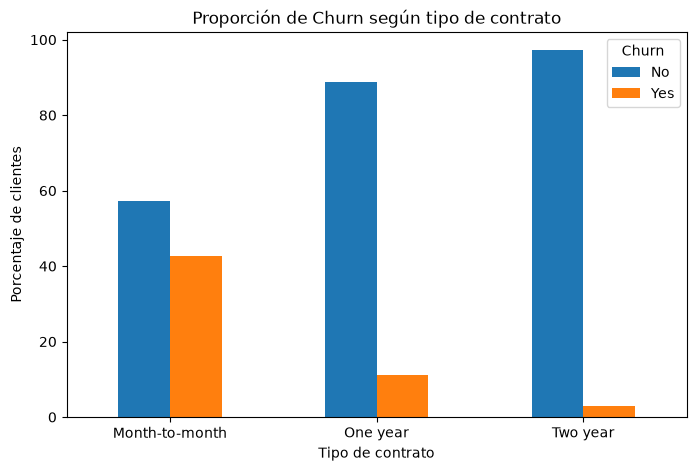

In [50]:
contract_churn_pct.plot(kind="bar", figsize=(8, 5))

plt.title("Proporción de Churn según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Porcentaje de clientes")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

### Interpretación

El tipo de contrato presenta diferencias importantes en la proporción de churn. Los clientes con contrato mes a mes presentan la mayor proporción de abandono, con un 42,71 %, frente al 11,27 % de los contratos de un año y el 2,83 % de los contratos de dos años.

Además, los contratos mes a mes representan el grupo con mayor número de clientes. Los contratos de uno y dos años tienen volúmenes más similares entre sí, pero presentan proporciones de churn considerablemente menores.

En este dataset se observa, por tanto, que los contratos de mayor duración están asociados con una menor proporción de churn. Esta relación corresponde a una asociación observada y no implica por sí sola causalidad.

## 3. Relación entre cargos mensuales y Churn

Se analiza la distribución de `MonthlyCharges` entre los clientes que permanecen en la compañía y aquellos que presentan `Churn`, con el propósito de identificar posibles diferencias en los cargos mensuales de ambos grupos.

In [51]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


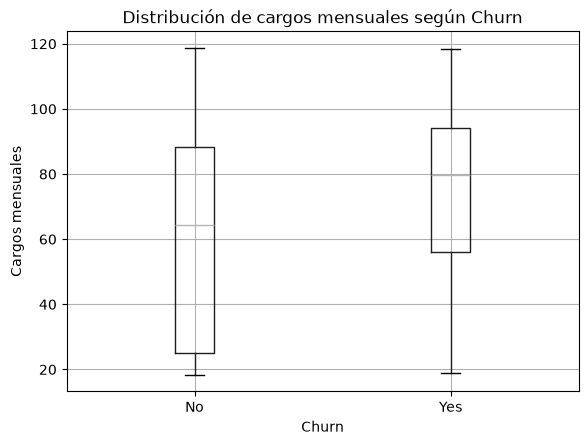

In [52]:
df.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Distribución de cargos mensuales según Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Cargos mensuales")
plt.show()

### Interpretación

Los clientes que presentan `Churn` muestran cargos mensuales más altos que aquellos que permanecen en la compañía. La mediana de `MonthlyCharges` es de 79,65 para los clientes con `Churn = Yes`, frente a 64,43 para `Churn = No`.

La diferencia también se observa en el primer cuartil, que alcanza 56,15 en los clientes que abandonan frente a 25,10 en quienes permanecen. Por otra parte, el grupo sin churn presenta una mayor dispersión en los cargos mensuales.

No se observan valores atípicos mediante el criterio utilizado por el boxplot. En este dataset, los cargos mensuales más altos muestran una asociación con una mayor presencia de churn, sin que esto implique una relación causal.

## 4. Relación entre tipo de servicio de Internet y Churn

Se analiza la proporción de clientes que presentan `Churn` dentro de cada tipo de servicio de Internet, con el propósito de identificar posibles diferencias en la frecuencia de abandono entre las distintas modalidades del servicio.

In [64]:
internet_churn = churn_count(df, "InternetService")
internet_churn_pct = churn_percentage(df, "InternetService")

display(internet_churn)
display(internet_churn_pct)

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


<function matplotlib.pyplot.show(close=None, block=None)>

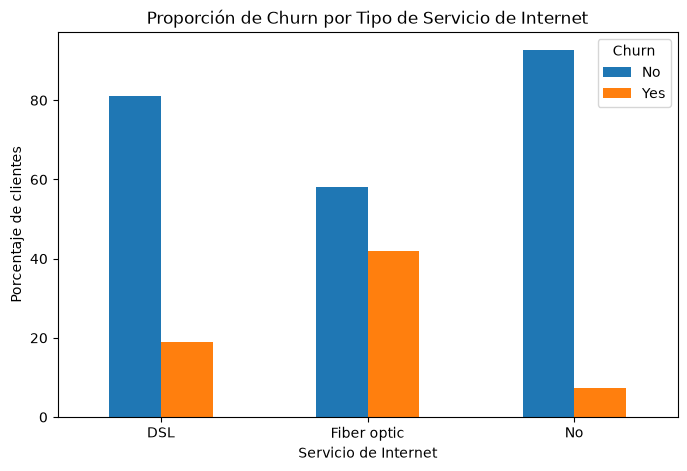

In [73]:
internet_churn_pct.plot(kind='bar', figsize=(8, 5))
plt.title('Proporción de Churn por Tipo de Servicio de Internet')
plt.xlabel('Servicio de Internet')
plt.ylabel('Porcentaje de clientes')
plt.xticks(rotation=0)
plt.legend(title = "Churn")
plt.show



### Interpretación

La proporción de churn presenta diferencias según el tipo de servicio de Internet. Los clientes con servicio de fibra óptica muestran la mayor proporción de churn, con aproximadamente un 42 %, mientras que los clientes con DSL presentan una proporción cercana al 19 %. Por su parte, los clientes que no cuentan con servicio de Internet presentan la menor proporción de churn, cercana al 7 %.

Además de concentrar un volumen importante de clientes, el servicio de fibra óptica presenta una proporción de churn considerablemente mayor que las demás categorías. En este dataset se observa, por tanto, una asociación entre el tipo de servicio de Internet y la presencia de churn, sin que esto implique una relación causal.

## 5. Relación entre método de pago y Churn

Se analiza la proporción de clientes que presentan `Churn` dentro de cada método de pago, con el propósito de identificar posibles diferencias en la frecuencia de abandono entre las distintas formas de pago.

In [65]:
payment_method_churn = churn_count(df, "PaymentMethod")
payment_method_churn_pct = churn_percentage(df, "PaymentMethod")

display(payment_method_churn)
display(payment_method_churn_pct)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


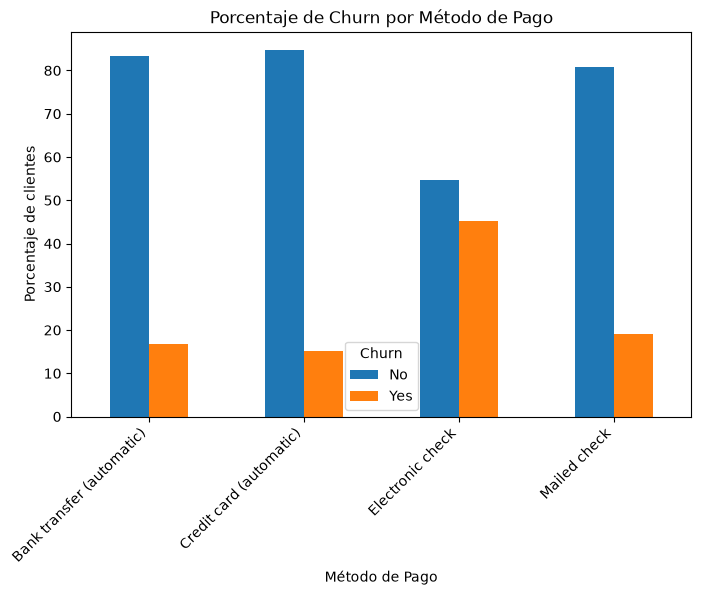

In [72]:
payment_method_churn_pct.plot(kind='bar', figsize=(8,5))
plt.title('Porcentaje de Churn por Método de Pago')
plt.xticks(rotation=45, ha="right")
plt.legend(title='Churn')
plt.xlabel('Método de Pago')
plt.ylabel('Porcentaje de clientes')
plt.show()

### Interpretación

El método de pago presenta diferencias importantes en la proporción de churn. Los clientes que utilizan `Electronic check` muestran la mayor proporción de abandono, con un 45,29 %, considerablemente superior a la observada en `Bank transfer (automatic)` (16,71 %), `Credit card (automatic)` (15,24 %) y `Mailed check` (19,11 %).

Además, `Electronic check` concentra 1.071 clientes con churn, por lo que la diferencia observada no corresponde únicamente al volumen de clientes, sino también a una mayor proporción de abandono dentro de este método de pago.

En este dataset se observa una asociación entre el método de pago y la presencia de churn, sin que esto implique una relación causal.

## 6. Relación entre servicios adicionales y Churn

Se analiza la proporción de `Churn` según la contratación de diferentes servicios adicionales asociados al servicio de Internet, con el propósito de identificar posibles diferencias en la frecuencia de abandono entre los clientes que cuentan o no con cada servicio.

In [74]:
additional_services = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

In [77]:
service_summary = []

for service in additional_services:
    service_pct = churn_percentage(df, service)

    service_summary.append({
        "Servicio": service,
        "Sin servicio (%)": service_pct.loc["No", "Yes"],
        "Con servicio (%)": service_pct.loc["Yes", "Yes"]
    })

service_summary = pd.DataFrame(service_summary)

service_summary["Diferencia (pp)"] = (
    service_summary["Sin servicio (%)"]
    - service_summary["Con servicio (%)"]
).round(2)

display(service_summary)

,Servicio,Sin servicio (%),Con servicio (%),Diferencia (pp)
0,OnlineSecurity,41.77,14.61,27.16
1,OnlineBackup,39.93,21.53,18.40
2,DeviceProtection,39.13,22.50,16.63
3,TechSupport,41.64,15.17,26.47
4,StreamingTV,33.52,30.07,3.45
5,StreamingMovies,33.68,29.94,3.74
